In [28]:
import json
import numpy as np
import copy
import stim
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Load code

In [5]:
dict_load = json.load(open('../CNOT order/UnfoldedCode.json', 'r'))

# stabilizers of unfolded code
stabilizers = dict_load['stabilzers']
# stabilizer types (X or Z)
stabilizer_type = np.array(dict_load['stabilizer_type'])
# qubits hosting the 15 XL rotations
rotations = np.array(dict_load['rotations'])
# information qubits where XL = X
info_qubits = dict_load['info_qubits']
# repetition code outputting the magic state
out_qubits = dict_load['out_qubits']
# the 5 logical qubits
Logical_qubits = dict_load['logical_qubits']

# distance against bit-flip errors
dx = dict_load['dx']
# distance against phase-flip errors
dz = dict_load['dz']

# number of ancilla qubits
nb_ancilla = len(stabilizers)

# stabilizers list (without timestep formatting)
stabilizers_flatten = []

for i in range(len(stabilizers)):
    stabilizers_flatten.append([])
    for j in range(len(stabilizers[i])): 
        for k in range(len(stabilizers[i][j])):
            if type(stabilizers[i][j][k]) == int:
                stabilizers_flatten[i].append(stabilizers[i][j][k])

stabilizers_flatten = [list(set(sublist)) for sublist in stabilizers_flatten]
max_len = max(len(sublist) for sublist in stabilizers_flatten)
stabilizers_flatten = np.array([sublist + [np.nan] * (max_len - len(sublist)) for sublist in stabilizers_flatten])

# number of data qubits
nb_data = int(np.nanmax(stabilizers_flatten)) + 1

# stabilizers involved in the surface code only
out_stabilizers = np.where(np.all(np.isin(stabilizers_flatten,out_qubits) | np.isnan(stabilizers_flatten),axis = 1))[0]

# Z stabilizer of the surface code that should not be measure 
# because of lattice surgery
merged_Z_stab = np.argmax(stabilizer_type == 'Z')

# Byproducts

In [6]:
# As first round of X stabilizer is random
# tracks the byproduct for each qubit
byproducts = [[] for _ in range(nb_data)]

# iteratively computes the byproducts
processed_qubits = np.zeros(nb_data,dtype = int)
# information qubits are chosen to have no byproduct
processed_qubits[info_qubits] = 1

while np.any(processed_qubits == 0):
            
    # iterate through all stabilizers
    for shape_index, shape in enumerate(stabilizers_flatten):
        
        if stabilizer_type[shape_index] == 'X':

            shape = shape[~np.isnan(shape)].astype(int)
            shape_processed = processed_qubits[shape]

            # if only one qubit in the stabilizer has no byproduct yet
            if np.sum(shape_processed) == len(shape_processed)-1:

                next_qubit_shape_index = np.where(shape_processed == 0)[0][0]
                next_qubit_data_index = shape[next_qubit_shape_index]

                # take sum%2 of the other qubit byproducts
                for qubit in shape:
                    if qubit != next_qubit_data_index:
                        byproducts[next_qubit_data_index] += byproducts[qubit]

                # add current stabilizer in the byproduct
                byproducts[next_qubit_data_index].append(shape_index)

                processed_qubits[next_qubit_data_index] = 1

# remove duplicate stabilizers
for index,sublist in enumerate(byproducts):
    count = Counter(sublist)
    new_sublist = [num for num, freq in count.items() if freq % 2 == 1]
    byproducts[index] = new_sublist

# Gate order

In [7]:
def Gate_Order(rounds):
    
    # first round of stabilizer measurements
    stabilizers_first = []

    for i in range(len(stabilizers)):
        stabilizers_first.append([])
        for j in range(len(stabilizers[i])):
            stabilizers_first[i].append(stabilizers[i][j])
            if stabilizers[i][j] == ['M']:
                break

    for i in range(len(stabilizers_first)):
        while len(stabilizers_first[i]) < 6:
            stabilizers_first[i].append([])

    # middle rounds
    stabilizers_middle = []

    for i in range(len(stabilizers)):
        stabilizers_middle.append([])
        for j in range(len(stabilizers[i])):
            stabilizers_middle[i].append(stabilizers[i][j])
            if stabilizers[i][j] == ['M']:
                break

    for i in range(len(stabilizers_middle)):
        stabilizers_middle[i] = stabilizers_middle[i][-6:]

    stabilizers_middle_end = copy.deepcopy(stabilizers_middle)

    for i in range(len(stabilizers_middle)):
        while len(stabilizers_middle[i]) < 6:
            stabilizers_middle[i].append([])

    # last round
    stabilizers_final = []

    for i in range(len(stabilizers)):
        stabilizers_final.append([])
        bool_measure = False
        for j in range(len(stabilizers[i])):
            if bool_measure:
                stabilizers_final[i].append(stabilizers[i][j])
            if stabilizers[i][j] == ['M']:
                bool_measure = True

    stabilizers_final_only = []

    for i in range(len(stabilizers)):
        stabilizers_final_only.append([])
        for j in range(len(stabilizers[i])-1,-1,-1):
            stabilizers_final_only[i].insert(0,stabilizers[i][j])
            if stabilizers[i][j] == ['P']:
                break

    max_length = max(len(stab) for stab in stabilizers_final_only)

    for stab in stabilizers_final_only:
        while len(stab) < max_length:
            stab.insert(0, [])

    # construct gate order from stabilizers first, middle and final
    if rounds == 1:
        gate_order = copy.deepcopy(stabilizers_final_only)
    elif rounds == 2:
        gate_order = stabilizers
    else:
        gate_order = copy.deepcopy(stabilizers_first)

        for i in range(rounds-3):
            for j in range(nb_ancilla):
                gate_order[j] += stabilizers_middle[j]

        for j in range(nb_ancilla):
            gate_order[j] += stabilizers_middle_end[j]

        for j in range(nb_ancilla):
            gate_order[j] += stabilizers_final[j]

        max_step = max([len(gate_order[j]) for j in range(nb_ancilla)])
        for j in range(nb_ancilla):
            while len(gate_order[j]) < max_step:
                gate_order[j].append([])
                
    return gate_order

# Create Circuit

In [8]:
def CreateCircuit(rounds):
    
    # store measurement number on ancilla qubits
    measurement_number = [[] for _ in range(nb_ancilla + len(stabilizers) - len(out_stabilizers))]
    counter = 0
    
    gate_order = Gate_Order(rounds)
    
    circuit = stim.Circuit()
    
    # preparation data
    circuit.append('R',range(nb_data))
    
    # iterate through timesteps
    for i in range(len(gate_order[0])):   
        
        # list of detectors to add at step i
        detectors_to_add = []
        
        for j in range(nb_ancilla):
            
            # preparation
            if gate_order[j][i] == ['P']:
                # X stabilizers
                if stabilizer_type[j] == "X":
                    circuit.append('RX',nb_data + j)
                    if i+1<len(gate_order[0]) and gate_order[j][i+1] == ['Fup']:
                        circuit.append('R',nb_data + nb_ancilla + j)
                # Z stabilizers
                if stabilizer_type[j] == "Z":
                    if j!= merged_Z_stab:
                        circuit.append('R',nb_data + j)
                    
            # measurement
            if gate_order[j][i] == ['M']:
                # X stabilizers
                if stabilizer_type[j] == "X":
                    circuit.append('MX',nb_data + j)
                    measurement_number[j].append(counter)
                    if len(measurement_number[j])>1:
                        detectors_to_add.append([measurement_number[j][-1], measurement_number[j][-2]])
                    counter += 1
                    # flag qubit measurement
                    if i-1>0 and gate_order[j][i-1] == ['Fdo']:
                        circuit.append('M',nb_data + nb_ancilla + j)
                        measurement_number[nb_ancilla + j].append(counter)
                        detectors_to_add.append([measurement_number[nb_ancilla + j][-1]])
                        counter += 1
                # Z stabilizers
                if stabilizer_type[j] == "Z":
                    if j!= merged_Z_stab:
                        circuit.append('M',nb_data + j)
                        measurement_number[j].append(counter)
                        # store detector
                        if len(measurement_number[j])>1:
                            detectors_to_add.append([measurement_number[j][-1], measurement_number[j][-2]])
                        else:
                            detectors_to_add.append([measurement_number[j][-1]])
                        counter += 1
                    
            # flag qubit
            if gate_order[j][i] == ['Fup'] or gate_order[j][i] == ['Fdo']:
                circuit.append('CX',[nb_data + j, nb_data + nb_ancilla + j])
                
            # CNOT gate
            if len(gate_order[j][i])>=1 and type(gate_order[j][i][0]) == int:
                # single CNOT gate
                if len(gate_order[j][i])==1:
                    if stabilizer_type[j] == 'X':
                        circuit.append('CX',[nb_data + j,gate_order[j][i][0]])
                    if stabilizer_type[j] == 'Z':
                        if j!= merged_Z_stab:
                            circuit.append('CX',[gate_order[j][i][0],nb_data + j])
                # two CNOT gates with flag qubit
                if len(gate_order[j][i])==2:
                    circuit.append('CX',[nb_data + j,gate_order[j][i][0]])
                    circuit.append('CX',[nb_data + nb_ancilla + j,gate_order[j][i][1]])
                # flag qubit preparation
                if i+1<len(gate_order[0]) and gate_order[j][i+1] == ['Fup']:
                    circuit.append('R',nb_data + nb_ancilla + j)
                # flag qubit measurement
                if i-1>0 and gate_order[j][i-1] == ['Fdo']:
                    circuit.append('M',nb_data + nb_ancilla + j)
                    measurement_number[nb_ancilla + j].append(counter)
                    detectors_to_add.append([measurement_number[nb_ancilla + j][-1]])
                    counter += 1

            # flag operation during idle ancilla time
            if len(gate_order[j][i])==0:
                # flag qubit preparation
                if i+1<len(gate_order[0]) and gate_order[j][i+1] == ['Fup']:
                    circuit.append('R',nb_data + nb_ancilla + j)
                # flag qubit measurement
                if i-1>0 and gate_order[j][i-1] == ['Fdo']:
                    circuit.append('M',nb_data + nb_ancilla + j)
                    measurement_number[nb_ancilla + j].append(counter)
                    detectors_to_add.append([measurement_number[nb_ancilla + j][-1]])
                    counter += 1
                       
        ## add detectors
        # total number of measurement up to step i
        tot_meas = sum(len(sublist) for sublist in measurement_number)
        for detector in detectors_to_add:
            if len(detector) ==1:
                circuit.append('DETECTOR',[stim.target_rec(-tot_meas+detector[0])])
            if len(detector) ==2:
                circuit.append('DETECTOR',[stim.target_rec(-tot_meas+detector[0]),stim.target_rec(-tot_meas+detector[1])])

        if i==len(gate_order[0])-3:
            circuit.append('I',out_qubits[0])
                
        circuit.append('TICK')

    # total number of ancilla measurement
    tot_meas = sum(len(sublist) for sublist in measurement_number)
        
    # Transversal X^1/2 gate 
    circuit.append('SQRT_X',rotations)
            
    circuit.append('TICK')
        
    # Z measurements unfolded code
    circuit.append('M',[i for i in range(nb_data) if i not in out_qubits])
    
    # distillation check of logical qubit 1 and 4
    for i in [1,3]:
        # raw observable
        raw_observable = [stim.target_rec(-nb_data+len(out_qubits)+j) for j in Logical_qubits[i]]
                  
        ## normalize with byproducts
        updated_logical_qubits = np.intersect1d(rotations,np.array(Logical_qubits[i]))   
        Logical_Qubit_byproduct = [stab for j in updated_logical_qubits for stab in byproducts[j]]   
        # keep only odd counter of stabilizers
        count = Counter(Logical_Qubit_byproduct)
        Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]
        # first round of random X stabilizers byproducts
        first_round_byproduct = [stim.target_rec(-nb_data+len(out_qubits)-tot_meas+measurement_number[j][0]) for j in Logical_Qubit_byproduct]
            
        # distillation observable
        circuit.append('OBSERVABLE_INCLUDE',raw_observable + first_round_byproduct,i)
        
    circuit.append('TICK')
    
    ## perfect round surface code stabilizer
    # preparation ancilla surface code
    for j in out_stabilizers:
        if stabilizer_type[j] == "X":
            circuit.append('RX',nb_data + j)
        if stabilizer_type[j] == "Z":
            circuit.append('R',nb_data + j)
    
    # CX gates
    for k in range(4):
        for j in out_stabilizers:
            if len(stabilizers[j][1+k])>0 and type(stabilizers[j][1+k][0]) == int:
                if stabilizer_type[j] == "X":
                    circuit.append('CX',[nb_data + j,stabilizers[j][1+k][0]])
                if stabilizer_type[j] == "Z":
                    circuit.append('CX',[stabilizers[j][1+k][0],nb_data + j])
        circuit.append('TICK')
    
    # measurement ancilla
    for j in out_stabilizers:
        if stabilizer_type[j] == "X":
            circuit.append('MX',nb_data + j)
        if stabilizer_type[j] == "Z":
            circuit.append('M',nb_data + j)
            
    # detector
    for index,j in enumerate(out_stabilizers):
        if j != merged_Z_stab:
            circuit.append('DETECTOR',[stim.target_rec(-len(out_stabilizers) + index),
                                       stim.target_rec(-len(out_stabilizers) -nb_data +len(out_qubits) -tot_meas + measurement_number[j][-1])])
            
    # distillation check of logical qubit 0 and 2
    for i in [0,2]:
        logical_qubit_unfolded_code = [qubit for qubit in Logical_qubits[i] if qubit < nb_data-len(out_qubits)]

        # raw observable
        raw_observable = [stim.target_rec(-nb_data+len(out_qubits)-len(out_stabilizers)+j) for j in logical_qubit_unfolded_code]

        # first stabilizer round normalization    
        updated_logical_qubits = np.intersect1d(rotations,logical_qubit_unfolded_code)
        Logical_Qubit_byproduct = [stab for j in updated_logical_qubits for stab in byproducts[j]]   
        # remove even occurrences
        count = Counter(Logical_Qubit_byproduct)
        Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]

        # create observable normalization  
        first_round_byproduct = [stim.target_rec(-nb_data+len(out_qubits)-len(out_stabilizers)-tot_meas+measurement_number[j][0]) for j in Logical_Qubit_byproduct]

        # Z stabilizer measured again at the end
        stab_Z = [stim.target_rec(-len(out_stabilizers)+(int(dx/2)+1)*(dz-1))]

        circuit.append('OBSERVABLE_INCLUDE',raw_observable + first_round_byproduct + stab_Z,i)

    # Y measurement surface code
    circuit.append('MY',[nb_data - len(out_qubits) + i for i in range(dx*dz)])
    
    ## Y observable
    # raw observable
    raw_observable = [stim.target_rec(-dx*dz+i) for i in range(dx*dz)]
    
    # Z feedback from unfolded code
    feedbackZ_qubits = np.setdiff1d(Logical_qubits[4],out_qubits)
    feedbackZ_observable = [stim.target_rec(-nb_data -len(out_stabilizers) + qubit) for qubit in feedbackZ_qubits]
        
    # Z feedback round normalization
    updated_logical_qubits = np.intersect1d(Logical_qubits[4],rotations)
    Logical_Qubit_byproduct = [stab for j in updated_logical_qubits for stab in byproducts[j]]
    # remove even occurrences
    count = Counter(Logical_Qubit_byproduct)
    Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]
    byproduct_observable = [stim.target_rec(-tot_meas -nb_data -len(out_stabilizers) +measurement_number[j][0]) for j in Logical_Qubit_byproduct]    
    
    # surface code byproduct
    Logical_Qubit_byproduct = [stab for j in out_qubits for stab in byproducts[j]]
    count = Counter(Logical_Qubit_byproduct)
    Logical_Qubit_byproduct = [num for num, freq in count.items() if freq % 2 == 1]
    surface_code_byproduct = [stim.target_rec(-tot_meas -nb_data -len(out_stabilizers) +measurement_number[j][0]) for j in Logical_Qubit_byproduct]    
    
    circuit.append('OBSERVABLE_INCLUDE',raw_observable + byproduct_observable + feedbackZ_observable + surface_code_byproduct,4)

    return circuit, measurement_number

# Add Noise

In [11]:
def AddNoise(circuit,px,pz):

    # circuit with noise to be added
    result = stim.Circuit()

    # qubit acted on by gates in current timestep
    qubit_processed = []
    
    # remove the noise in final round of perfect stabilizer measurement of surface code
    final_round = False

    for instruction_index,instruction in enumerate(circuit):
        
        # ignore final round instruction if in unfolded code
        if len(instruction.targets_copy())>0:
            qv = instruction.targets_copy()[0].qubit_value
            if qv is not None:
                ignore_final_round = qv < out_qubits[0] or nb_data <= qv < nb_data + out_stabilizers[0] or qv >= nb_data + nb_ancilla
        
        # preparation
        if instruction.name == 'RX' or instruction.name == 'R':
            result.append(instruction)
            if final_round == False or ignore_final_round:
                result.append("PAULI_CHANNEL_1",[target.qubit_value for target in instruction.targets_copy()],[px,0,pz])
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

        # measurement
        elif instruction.name == 'MX' or instruction.name == 'M':
            if final_round == False or ignore_final_round:
                result.append("PAULI_CHANNEL_1",[target.qubit_value for target in instruction.targets_copy()],[px,0,pz])
            result.append(instruction)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

        # CNOT
        elif instruction.name == 'CX':       
            result.append(instruction)
            if final_round == False or ignore_final_round:
                result.append("PAULI_CHANNEL_2",[target.qubit_value for target in instruction.targets_copy()],
				[px/3,0,pz/3,px/3,px/3,0,0,0,0,0,0,pz/3,0,0,pz/3])
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]
            
        # X^1/2
        elif instruction.name == 'SQRT_X':
            result.append(instruction)
            result.append("DEPOLARIZE1",[target.qubit_value for target in instruction.targets_copy()],pz)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]
            
        # add idle noise on unacted qubits
        elif instruction.name == 'TICK':
            for i in range(circuit.num_qubits):
                if i not in qubit_processed:
                    ignore_final_round = i < out_qubits[0] or nb_data <= i < nb_data + out_stabilizers[0] or i >= nb_data + nb_ancilla
                    if final_round == False or ignore_final_round:
                        result.append("PAULI_CHANNEL_1",i,[px,0,pz])
            result.append(instruction)
            qubit_processed = []
            
        # I instruction signaling final round
        elif instruction.name == 'I':
            result.append(instruction)
            final_round = True
            
        else:
            result.append(instruction)
            qubit_processed += [target.qubit_value for target in instruction.targets_copy()]

    circuit = result
    
    return circuit

In [13]:
px_list = np.logspace(-7,np.log10(5e-5),10)
px = px_list[7]
px

1.2566053148961804e-05

# Simulations

In [14]:
# physical bit-flip error rate
px_list = np.logspace(-7,np.log10(5e-5),10)
px = px_list[7] # can take any, bit-flip error will not change preselection
# number of X stabilizer measurement round
rounds = 100

# create circuit
circuit, detector_order = CreateCircuit(rounds = rounds)
circuit = AddNoise(circuit, px = 0, pz = 1e-3)

# sample circuit
sampler = circuit.compile_detector_sampler()
batch_size = 100_000
detection_events, observables = sampler.sample(batch_size, separate_observables=True)

In [15]:
### remove first round from detector order
for index,sublist in enumerate(detector_order):
    if index<len(stabilizer_type) and stabilizer_type[index] == "X":
        removed_element = sublist[0]
        sublist.remove(removed_element)

        # reduce numbers higher by 1
        for i in range(len(detector_order)):
            for j in range(len(detector_order[i])):
                if detector_order[i][j]>removed_element:
                    detector_order[i][j] -= 1

# Example : preselection = 2

In [16]:
# start preselection only if at least *min_rounds* have been performed
min_rounds = 8

# number of rounds of preselection
preselection = 2

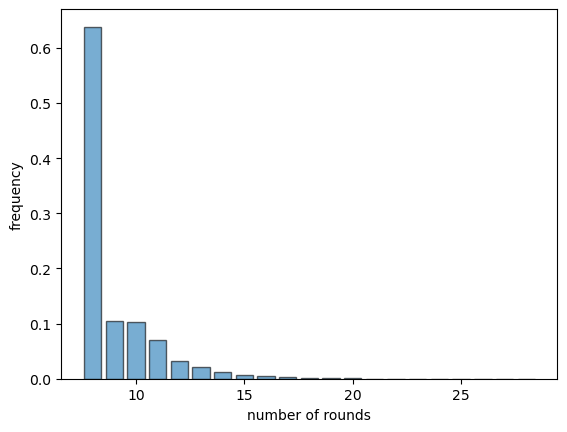

In [17]:
# store for all sample and all rounds 
# if the last *preselection* rounds are trivial
is_preselected = np.zeros((batch_size,rounds-preselection),dtype = bool)
for i in range(rounds-preselection):
    preselected_detectors = np.array(detector_order[:np.min(out_stabilizers)])[:,i:i+preselection].flatten()
    is_preselected[:,i] = np.all(detection_events[:,preselected_detectors] == False,axis = 1)
    
# check that are enough total rounds for preselection
assert np.all(is_preselected[:,max(min_rounds-(1+preselection),0):].any(axis=1))
    
# check first round where preselection condition is met
first_preselect = np.argmax(is_preselected[:,max(min_rounds-(1+preselection),0):], axis=1) + max(min_rounds,preselection+1)

# compute frequency
counter = Counter(first_preselect)
keys = np.array(list(counter.keys()))
values = np.array(list(counter.values()))/batch_size

# sort keys
sorted_indices = np.argsort(keys)
# Apply the sorted indices
keys = keys[sorted_indices]
values = values[sorted_indices]

# Plot histogram
plt.bar(keys, values, width=0.8, edgecolor="black", alpha=0.6)
plt.xlabel("number of rounds")
plt.ylabel("frequency")
plt.show()

In [20]:
mean = sum(keys*values)
print(f'mean number of rounds: {mean}')
estimated_variance = np.sum((first_preselect-mean)**2)/batch_size
error_bar = np.sqrt(estimated_variance/batch_size)
print(f'error bar: {error_bar}')

mean number of rounds: 8.973490000000002
error bar: 0.005424949050359828


# Vary preselection

In [26]:
# mean number of rounds for varying preselection rounds
Mean_rounds = np.zeros((3))
# mean number of rounds uncertainty
Mean_rounds_u = np.zeros((3))

# start preselection only if at least *min_rounds* have been performed
min_rounds = 8

# number of preselected rounds
preselect_list = range(1,4)

for index,preselection in enumerate(preselect_list):
    
    # store for all sample and all rounds 
    # if the last *preselection* rounds are trivial
    is_preselected = np.zeros((batch_size,rounds-preselection),dtype = bool)
    for i in range(rounds-preselection):
        preselected_detectors = np.array(detector_order[:np.min(out_stabilizers)])[:,i:i+preselection].flatten()
        is_preselected[:,i] = np.all(detection_events[:,preselected_detectors] == False,axis = 1)
    
    # check that are enough total rounds for preselection
    assert np.all(is_preselected[:,max(min_rounds-(1+preselection),0):].any(axis=1))
    
    # check first round where preselection condition is met
    first_preselect = np.argmax(is_preselected[:,max(min_rounds-(1+preselection),0):], axis=1) + max(min_rounds,preselection+1)

    Mean_rounds[index] = np.mean(first_preselect)
    estimated_variance = np.sum((first_preselect-mean)**2)/batch_size
    error_bar = np.sqrt(estimated_variance/batch_size)
    Mean_rounds_u[index] = error_bar

In [35]:
column_names = [f"{i} round(s) of preselection" for i in preselect_list]
row_names = ["Mean number of rounds"]
df = pd.DataFrame(Mean_rounds.reshape(1,-1), columns=column_names, index=row_names)
df

,1 round(s) of preselection,2 round(s) of preselection,3 round(s) of preselection
Mean number of rounds,8.40514,8.97349,9.84076


# Include flag, complementary gap, distillation acceptance

In [36]:
# number of jobs
job_number = 100

# physical bit-flip error rate
px_list = np.logspace(-7,np.log10(5e-5),10)

# Save acceptance
Acceptance = np.full((len(preselect_list),len(px_list)),np.nan)
# Save acceptance uncertainty
Acceptance_u = np.full((len(preselect_list),len(px_list)),np.nan)

# loop through preselected rounds
for index_preselect,preselect in enumerate(preselect_list):
    # loop through bitflip error rate
    for index_px in range(len(px_list)):
        nb_accepted = 0
        nb_preselected = 0
        
        # loop through jobs
        for index in range(job_number):
            result = json.load(open(f'Results/result_{index_px}_{index}.json', 'r'))
            nb_accepted += result['preselected&accepted&noflag&gap'][preselect]
            nb_preselected += result['preselected'][preselect]

        if nb_preselected != 0:
            Acceptance[index_preselect,index_px] = nb_accepted/nb_preselected
            Acceptance_u[index_preselect,index_px] = np.sqrt(nb_accepted/nb_preselected*(1-nb_accepted/nb_preselected)/nb_preselected)

In [37]:
# update mean number of rounds
Mean_number_rounds = np.zeros(Acceptance.shape)
Max_mean_number_rounds = np.zeros(Acceptance.shape)
Min_mean_number_rounds = np.zeros(Acceptance.shape)

for index_preselect,preselect in enumerate(preselect_list):
    for index_px in range(len(px_list)):
        mean = Mean_rounds[index_preselect]
        mean_u = Mean_rounds_u[index_preselect]
        acceptance = Acceptance[index_preselect,index_px]
        acceptance_u = Acceptance_u[index_preselect,index_px]
        Mean_number_rounds[index_preselect,index_px] = mean/acceptance
        Max_mean_number_rounds[index_preselect,index_px] = (mean+1.96*mean_u)/(acceptance-1.96*acceptance_u)
        Min_mean_number_rounds[index_preselect,index_px] = (mean-1.96*mean_u)/(acceptance+1.96*acceptance_u)

In [40]:
print('Mean number of rounds')
column_names = [f"px = {px_list[i]:.2e}" for i in range(10)]
row_names = [f"{i} round(s) of preselection" for i in preselect_list]
df = pd.DataFrame(Mean_number_rounds, columns=column_names, index=row_names)
df

Mean number of rounds


,px = 1.00e-07,px = 1.99e-07,px = 3.98e-07,px = 7.94e-07,px = 1.58e-06,px = 3.16e-06,px = 6.30e-06,px = 1.26e-05,px = 2.51e-05,px = 5.00e-05
1 round(s) of preselection,8.667895,8.670666,8.676189,8.687389,8.709465,8.754058,8.843479,9.024334,9.396758,10.006161
2 round(s) of preselection,9.252031,9.254922,9.260895,9.272784,9.296366,9.343976,9.439445,9.632534,10.029940,10.680381
3 round(s) of preselection,10.146188,10.149412,10.155952,10.168962,10.194814,10.247065,10.351751,10.563509,10.999341,11.712832


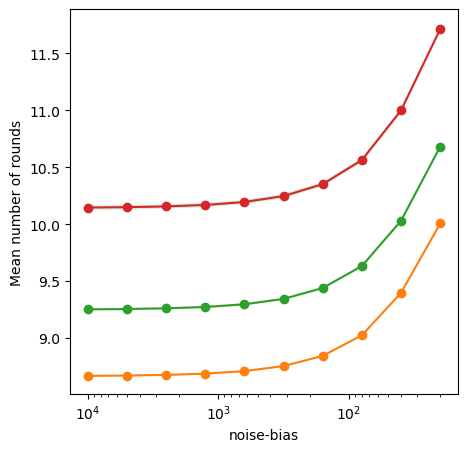

In [42]:
plt.figure(figsize=(5,5))         

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i in range(len(preselect_list)):
    # Mean rounds
    plt.plot(1e-3/px_list,Mean_number_rounds[i],'-o', c = color_cycle[i+1])
    # error bar
    plt.fill_between(1e-3/px_list, Min_mean_number_rounds[i], Max_mean_number_rounds[i], alpha=0.2)

plt.xscale('log')
plt.gca().invert_xaxis()

plt.xlabel('noise-bias')
plt.ylabel('Mean number of rounds')
plt.show()